# Evaluación de Sistemas de Aprendizaje Automática(ESAA)
## Análisis de ECG, Benchmarks de PTB-XL


---
Utilizamos un repositorio de Github llamado **"Deep Learning for ECG Analysis: Benchmarks and Insights from PTB-XL"** ([github.com/helme/ecg_ptbxl_benchmarking](https://github.com/helme/ecg_ptbxl_benchmarking)), el cual arma un benchmark para ver qué modelos de Deep Learning diagnostican mejor electrocardiogramas.

1. **Datos:**
    Se utiliza **PTB-XL**, un dataset público con casi 22.000 registros de ECG de al rededor de unos 19.000 pacientes.


2. **Problema:**
    Es un problema **multi-etiqueta** (un mismo paciente le pueden corresponder varios diagnósticos a la vez, como un infarto previo y además una arritmia). Se evalúan tareas como: diagnósticos generales (infarto, hipertrofia, etc.), morfología de la onda y tipos de ritmo cardíaco.

3. **Modelos:**
    En el GitHub hay implementados muchos modelos distintos, más adelante vamos a ver cuales nos quedamos.

4. **Metodos de evaluación vistos en la materia que vamos a realizar:**

  - **Costos:**

    Vamos a armar una matriz de costos para cada clase, donde cada una de las predicciones del modelo tenga una penalización acorde a la gravedad de su error. Luego, medimos qué modelo genera menor costo total.

  - **Calibración:**

    Las redes neuronales suelen sobreestimar esta predicción. Podríamos medir si las probabilidades son razonables y le aplicamos un ajuste simple para calibrar su confianza.

  - **Análisis por subgrupos:**

    Un sistema puede dar un promedio excelente a nivel general, pero fallar en una minoría. Como el dataset tiene edad y sexo, proponemos separamos las predicciones y fijarno si el modelo rinde de forma similar en distintos subgrupos.

  - **Domain Shift:**

    Los modelo fueron entrenados con datos de un centro de salud de Alemania. Proponemos evaluarlos sobre el dataset de un hospital en China (ICBEB) para ver si se ve afectado por el cambio de hospital.


#### **Para Domain Shift**

El dataset de **ICBEB** predice solo **9** clases. Por lo tanto, para este trabajo practico decidimos evaluar solo estas **9** en común dentro de las **71** que tiene el dataset de **PTB-XL**.

In [ ]:
# Instalación de dependencias para Google Colab o entorno local
!pip install -q wfdb pandas numpy matplotlib seaborn scipy

import os
import sys
import ast
import urllib.request
import zipfile
import shutil
import pickle
import warnings
warnings.filterwarnings('ignore')

try:
    from IPython.display import display
except ImportError:
    display = print

import numpy as np
import pandas as pd
import scipy.io
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.metrics import roc_auc_score

# Estilo básico para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

print('[OK] Librerías cargadas correctamente.')


In [ ]:
# Descarga de datos y preparación de carpetas
DATA_DIR = 'data'
PTB_DIR = os.path.join(DATA_DIR, 'ptbxl')
ICBEB_DIR = os.path.join(DATA_DIR, 'ICBEB')

os.makedirs(PTB_DIR, exist_ok=True)
os.makedirs(ICBEB_DIR, exist_ok=True)

# Clonar repositorio con modelos y código si estamos en Colab y no existe aún
if not os.path.exists('code') and not os.path.exists('ecg_ptbxl_benchmarking'):
    !git clone -q https://github.com/MarioSigal/ESAA_TP.git ecg_ptbxl_benchmarking

if os.path.exists('ecg_ptbxl_benchmarking/code'):
    sys.path.insert(0, 'ecg_ptbxl_benchmarking/code')
elif os.path.exists('code'):
    sys.path.insert(0, 'code')

from utils import utils

# Descarga de metadatos de PTB-XL (versión 1.0.1 alineada a los experimentos de referencia) y de ICBEB
def descargar(url, destino):
    if not os.path.exists(destino):
        print(f'Descargando {os.path.basename(destino)}...')
        urllib.request.urlretrieve(url, destino)
    else:
        print(f'Ya existe: {os.path.basename(destino)}')

descargar('https://physionet.org/files/ptb-xl/1.0.1/ptbxl_database.csv', os.path.join(PTB_DIR, 'ptbxl_database.csv'))
descargar('https://physionet.org/files/ptb-xl/1.0.1/scp_statements.csv', os.path.join(PTB_DIR, 'scp_statements.csv'))
descargar('http://2018.icbeb.org/file/REFERENCE.csv', os.path.join(ICBEB_DIR, 'REFERENCE.csv'))

print('[OK] Metadatos listos.')


In [ ]:
# Reconstruir la tabla de metadatos del test y comprobar que sus filas están en el mismo orden que y_test y p_test
folder = 'data/ptbxl/'
df = pd.read_csv(folder + 'ptbxl_database.csv', index_col='ecg_id')

df['scp_codes'] = df.scp_codes.apply(ast.literal_eval)   # Convertimos a diccionario
df = utils.compute_label_aggregations(df, folder, 'all') # Agrega scp_codes_len
df = df[df.scp_codes_len > 0]                            # Filtramos ECGs con al menos una etiqueta

df_test = df[df.strat_fold == 10]                        # El fold 10 es el conjunto de test
print('Total registros:', len(df), '| En test (fold 10):', len(df_test))

# Carpeta base de las salidas de los modelos
base = 'ecg_ptbxl_benchmarking/output/exp0/' if os.path.exists('ecg_ptbxl_benchmarking/output/exp0/') else 'output/exp0/'

y_test = np.load(base + 'data/y_test.npy', allow_pickle=True)
p_test = np.load(base + 'models/fastai_xresnet1d101/y_test_pred.npy', allow_pickle=True)
print('Dimensiones y_test y p_test:', y_test.shape, p_test.shape)
print('Macro AUC xresnet1d101 en test:', roc_auc_score(y_test, p_test, average='macro'))

# Comprobamos el orden exacto de las filas usando el MultiLabelBinarizer provisto
mlb = pickle.load(open(base + 'data/mlb.pkl', 'rb'))
y_check = mlb.transform(df_test.scp_codes.apply(lambda d: list(d.keys())))

orden_correcto = np.array_equal(y_check, y_test)
print('¿df_test está alineado 1 a 1 con y_test?:', orden_correcto)


# Análisis exploratorio

In [28]:
shape = df.shape
print("Número de filas:", shape[0])
print("Número de columnas:", shape[1])
print("Cantidad de pacientes:", df.patient_id.nunique())
print("Columnas:", np.array(df.columns))

Número de filas: 21799
Número de columnas: 29
Cantidad de pacientes: 18869
Columnas: ['patient_id' 'age' 'sex' 'height' 'weight' 'nurse' 'site' 'device'
 'recording_date' 'report' 'scp_codes' 'heart_axis' 'infarction_stadium1'
 'infarction_stadium2' 'validated_by' 'second_opinion'
 'initial_autogenerated_report' 'validated_by_human' 'baseline_drift'
 'static_noise' 'burst_noise' 'electrodes_problems' 'extra_beats'
 'pacemaker' 'strat_fold' 'filename_lr' 'filename_hr' 'scp_codes_len'
 'all_scp']


In [33]:
df_ptb = pd.read_csv(os.path.join(PTB_DIR, 'ptbxl_database.csv'), index_col='ecg_id')
scp_df = pd.read_csv(os.path.join(PTB_DIR, 'scp_statements.csv'), index_col=0)

# Convertir el string de scp_codes a diccionario de Python
df_ptb['scp_dict'] = df_ptb['scp_codes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})
df_ptb['num_labels'] = df_ptb['scp_dict'].apply(len)

print("=== RESUMEN GENERAL DE PTB-XL ===")
print(f"Total de registros de ECG: {len(df_ptb):,}")
print(f"Total de pacientes únicos: {df_ptb['patient_id'].nunique():,}")
print(f"Columnas disponibles ({len(df_ptb.columns)}):")
print(np.array(df_ptb.columns))
display(df_ptb[['patient_id', 'age', 'sex', 'height', 'weight', 'device', 'recording_date', 'num_labels', 'strat_fold']].head(5))


=== RESUMEN GENERAL DE PTB-XL ===
Total de registros de ECG: 21,799
Total de pacientes únicos: 18,869
Columnas disponibles (29):
['patient_id' 'age' 'sex' 'height' 'weight' 'nurse' 'site' 'device'
 'recording_date' 'report' 'scp_codes' 'heart_axis' 'infarction_stadium1'
 'infarction_stadium2' 'validated_by' 'second_opinion'
 'initial_autogenerated_report' 'validated_by_human' 'baseline_drift'
 'static_noise' 'burst_noise' 'electrodes_problems' 'extra_beats'
 'pacemaker' 'strat_fold' 'filename_lr' 'filename_hr' 'scp_dict'
 'num_labels']


,patient_id,age,sex,height,weight,device,recording_date,num_labels,strat_fold
ecg_id,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,CS-12 E,1984-11-09 09:17:34,3,3
2,13243.0,19.0,0,NaN,70.0,CS-12 E,1984-11-14 12:55:37,2,2
3,20372.0,37.0,1,NaN,69.0,CS-12 E,1984-11-15 12:49:10,2,5
4,17014.0,24.0,0,NaN,82.0,CS-12 E,1984-11-15 13:44:57,2,3
5,17448.0,19.0,1,NaN,70.0,CS-12 E,1984-11-17 10:43:15,2,4


In [ ]:
# Resumen de variables: Nombre, Tipo de dato y Porcentaje de faltantes (de mayor a menor)
resumen_vars = pd.DataFrame({
    'Tipo': df.dtypes.astype(str),
    '%': (df.isna().mean() * 100).round(1)
}).sort_values(by='%', ascending=False)
resumen_vars.index.name = 'Nombre'

display(resumen_vars)


*   height y weight casi no sirven: les falta el 68% y el 57%. No se pueden usar para subgrupos.
* Las columnas de ruido (baseline_drift, static_noise, burst_noise, electrodes_problems, extra_beats, pacemaker) tienen entre 85% y casi 100% de NaN. Probablemente NaN signifique "sin anotación", es decir, que no se registró ese problema en la señal, y no que falte el dato. Lo mismo vale para infarction_stadium1 y _2, que solo se llenan cuando hay infarto.
* validated_by_human es booleana y no tiene faltantes. Es la columna sobre la calidad de las etiquetas.

chequear

Edad, sexo y calidad de etiquetas por fold

In [34]:
# Edad: resumen y faltantes dentro del test
print(df.age.describe())
print("Sin edad en test:", df_test.age.isna().sum())

# Sexo: proporciones (normalize=True da proporciones en vez de conteos)
print(df.sex.value_counts(normalize=True))

# Registros validados por un humano en cada fold
# (crosstab: tabla de conteos que cruza dos variables)
print(pd.crosstab(df.strat_fold, df.validated_by_human))

count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64
Sin edad en test: 0
sex
0    0.52085
1    0.47915
Name: proportion, dtype: float64
validated_by_human  False  True 
strat_fold                      
1                     712   1463
2                     735   1446
3                     724   1468
4                     693   1481
5                     702   1472
6                     779   1394
7                     698   1478
8                     700   1473
9                       0   2183
10                      0   2198


In [ ]:
# Distribución de edad y sexo
# Mapeamos el sexo manteniendo todas las categorías (incluyendo NaN u otros si hubiera)
df['sex_label'] = df['sex'].map({0: 'Mujer (0)', 1: 'Varón (1)'}).fillna('Sin dato / NaN')

# 1. Histograma de edad discriminado por sexo (sin línea de KDE ni línea de media)
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='sex_label', bins=30, kde=False)
plt.title('Distribución de Edad por Sexo en PTB-XL')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de pacientes')
plt.show()

# 2. Gráfico de torta (rueda) de sexo incluyendo todas las categorías y NaNs
conteo_sexo = df['sex_label'].value_counts(dropna=False)
plt.figure(figsize=(5, 5))
plt.pie(conteo_sexo, labels=conteo_sexo.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución por Sexo en PTB-XL')
plt.show()


¿Cuántos positivos tiene cada clase en el test?

In [ ]:
# y_test tiene una columna por clase; sumar por columnas da los positivos de cada una
positivos = pd.Series(y_test.sum(axis=0), index=mlb.classes_).sort_values(ascending=False)

# Eje y logarítmico: cada línea de la grilla vale 10 veces la anterior
#positivos.plot.bar(logy=True, figsize=(14, 4))
#plt.ylabel('ECG positivos en test')
#plt.show()

print((positivos < 10).sum(), "clases con menos de 10 positivos")

22 clases con menos de 10 positivos


In [ ]:
# Las 22 clases con menos positivos en el test
print(positivos.tail(22))

EL        9
BIGU      8
WPW       8
ILBBB     8
AFLT      7
HVOLT     6
IPLMI     5
ISCAN     4
SEHYP     3
STE_      3
SVTAC     3
IPMI      3
TAB_      3
3AVB      2
PMI       2
INJLA     2
INJIL     2
INJIN     2
TRIGU     2
PSVT      2
2AVB      1
PRC(S)    1
dtype: int64


### Superclases diagnósticas y cantidad de etiquetas por ECG

En PTB-XL, las etiquetas de los diagnósticos siguen el estándar SCP-ECG y se pueden agrupar en **5 superclases principales** (usando el archivo `scp_statements.csv`):
- **NORM**: Trazado normal (sin patología detectada).
- **MI**: Infarto de miocardio (*Myocardial Infarction*).
- **STTC**: Cambios en el segmento ST y onda T (*ST/T Changes*).
- **CD**: Trastornos de conducción cardíaca (*Conduction Disturbance*, como bloqueos).
- **HYP**: Hipertrofias cardíacas (*Hypertrophy*).

Además, como es un problema multietiqueta, cada ECG puede tener desde una sola etiqueta hasta varias a la vez. A continuación vemos cuántos registros hay de cada superclase y la distribución de cantidad de códigos por trazado.


In [ ]:
# Mapeo de diagnósticos a las 5 superclases
scp_df = pd.read_csv(os.path.join(PTB_DIR, 'scp_statements.csv'), index_col=0)
diag_scp = scp_df[scp_df['diagnostic'] == 1.0]
diag_a_super = diag_scp['diagnostic_class'].dropna().to_dict()

def obtener_superclases(d):
    if not isinstance(d, dict): return []
    return list(set(diag_a_super[k] for k in d.keys() if k in diag_a_super))

df['superclasses'] = df['scp_codes'].apply(obtener_superclases)

# Conteo de casos de cada superclase
superclases = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
conteo_super = {sc: df['superclasses'].apply(lambda l: sc in l).sum() for sc in superclases}

# Gráfico de barras de las 5 superclases
plt.figure(figsize=(7, 4))
plt.bar(conteo_super.keys(), conteo_super.values(), color='steelblue')
plt.title('Cantidad de ECG por Superclase Diagnóstica en PTB-XL')
plt.xlabel('Superclase')
plt.ylabel('Cantidad de ECG')
for i, (k, v) in enumerate(conteo_super.items()):
    plt.text(i, v + 100, str(v), ha='center')
plt.show()

# Gráfico de cantidad de etiquetas SCP por ECG (cardinalidad)
plt.figure(figsize=(7, 4))
df['scp_codes_len'].value_counts().sort_index().plot(kind='bar', color='darkorange')
plt.title('Cantidad de etiquetas asignadas por ECG')
plt.xlabel('Número de etiquetas')
plt.ylabel('Cantidad de ECG')
plt.show()


Cuántas declaraciones tiene cada ECG?

Cada ECG de PTB-XL viene con un informe de cardiólogos, codificado con statements (declaraciones). Por ejemplo, NORM es ECG normal y SR es ritmo sinusal. Un ECG puede tener varias: por eso el problema es multietiqueta. scp_codes_len es cuántas tiene cada ECG. En total hay 71 declaraciones distintas del estándar SCP-ECG, que cubren aspectos diagnósticos, de forma y de ritmo. Según el paper son 44 diagnósticas, 12 de ritmo y 19 de forma (4 de las de forma cuentan también como diagnósticas). Esas 71 son las columnas de y_test y de p_test: el modelo devuelve una probabilidad por declaración.

Cada declaración viene con un número, {'NORM': 100.0, 'SR': 0.0}. Es la likelihood, y según el paper en las diagnósticas va de 15 a 100 y expresa la confianza del cardiólogo. En las demás, el valor es 0 cuando se desconoce. Vale la pena mencionar que una declaración con likelihood 15 cuenta igual de positiva que una con 100.



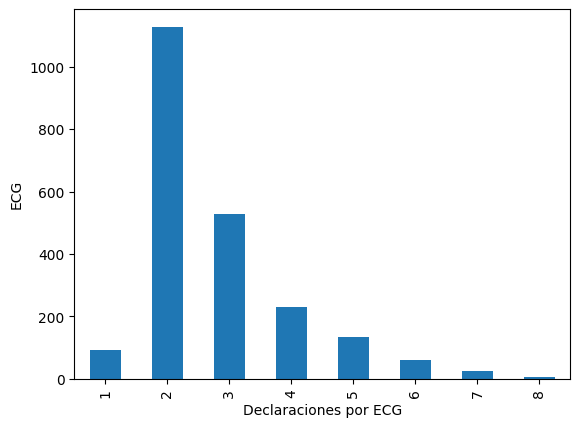

2203 ECG de 1907 pacientes


In [ ]:
# ECG del test según cantidad de declaraciones asignadas
df_test.scp_codes_len.value_counts().sort_index().plot.bar()
plt.xlabel('Declaraciones por ECG')
plt.ylabel('ECG')
plt.show()

print(len(df_test), "ECG de", df_test.patient_id.nunique(), "pacientes")

La mayoría tiene solo dos declaraciones...

In [ ]:
# Combinaciones más frecuentes entre los ECG con exactamente 2 declaraciones
dos = df_test[df_test.scp_codes_len == 2]
print(dos.all_scp.apply(lambda l: tuple(sorted(l))).value_counts().head(10))

# Promedio de declaraciones por ECG, y fracción de las 71 columnas que vale 1
print(y_test.sum(axis=1).mean(), y_test.mean())

all_scp
(NORM, SR)       673
(NDT, SR)         80
(NORM, SARRH)     34
(LAFB, SR)        29
(NORM, SBRAD)     28
(IMI, SR)         25
(CLBBB, SR)       23
(IRBBB, SR)       21
(NORM, STACH)     16
(NST_, SR)        15
Name: count, dtype: int64
2.772128915115751 0.03904406922698241


(NORM, SR) aparece en 673 ECG, alrededor del 31% de todo el test (673 de 2203).
El AUC macro promedia las 71 clases con el mismo peso. NORM y SR tienen mucha evidencia y son fáciles de discriminar, mientras que las 22 clases raras pesan igual y son muy ruidosas.

In [ ]:
scp = pd.read_csv(folder + 'scp_statements.csv', index_col=0)
print(scp.columns.tolist())

codigos = ['NORM', 'SR', 'NDT', 'SARRH', 'LAFB', 'SBRAD', 'IMI', 'CLBBB', 'IRBBB', 'STACH', 'NST_']
print(scp.loc[codigos].iloc[:, :6])

['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']
                                description  diagnostic  form  rhythm  \
NORM                             normal ECG         1.0   NaN     NaN   
SR                             sinus rhythm         NaN   NaN     1.0   
NDT          non-diagnostic T abnormalities         1.0   1.0     NaN   
SARRH                      sinus arrhythmia         NaN   NaN     1.0   
LAFB         left anterior fascicular block         1.0   NaN     NaN   
SBRAD                     sinus bradycardia         NaN   NaN     1.0   
IMI          inferior myocardial infarction         1.0   NaN     NaN   
CLBBB     complete left bundle branch block         1.0   NaN     NaN   
IRBBB  incomplete right bundle branch block         1.0   NaN     NaN   
STACH                     sinus tachycardia         NaN   NaN     1.0 

Algunas observaciones de esta tabla:
* diagnostic, form y rhythm dicen de qué tipo es la declaración
* Una declaración puede ser de más de un tipo. NDT (anomalías de onda T no diagnósticas) tiene 1.0 en diagnostic y en form.
* diagnostic_class es el grupo grande al que pertenece una declaración diagnóstica, la superclase. Hay 5: NORM (normal), MI (infarto), STTC (cambios del ST/T), CD (trastornos de conducción) y HYP (hipertrofia).
* Las declaraciones de ritmo tienen NaN en ambas columnas. No pertenecen a ninguna superclase. Si para la matriz de costos agrupamos en las 5 superclases, perdemos  todo lo de ritmo.
* Las de ritmo, como SR, tienen NaN en diagnostic_class porque no son diagnósticos y no entran en ninguna superclase.


# Función de costo

Todas las clases de ICBEB existen y se llaman igual en PTB-XL, menos la clase VPC, que aparece en PTB-XL como PVC.

Grupo de cada clase elegida:

In [ ]:
ptbxl_codes = ['NORM', 'AFIB', '1AVB', 'CLBBB', 'CRBBB', 'PAC', 'PVC', 'STD_', 'STE_']
scp.loc[ptbxl_codes, ['diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass']]

,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass
NORM,1.0,NaN,NaN,NORM,NORM
AFIB,NaN,NaN,1.0,NaN,NaN
1AVB,1.0,NaN,NaN,CD,_AVB
CLBBB,1.0,NaN,NaN,CD,CLBBB
CRBBB,1.0,NaN,NaN,CD,CRBBB
PAC,NaN,1.0,NaN,NaN,NaN
PVC,NaN,1.0,NaN,NaN,NaN
STD_,NaN,1.0,NaN,NaN,NaN
STE_,NaN,1.0,NaN,NaN,NaN


### Distribución de las 9 clases en el dataset ICBEB (China)

En el dataset de **ICBEB 2018 (China Physiological Signal Challenge)** se analizan 9 patologías diana. A continuación cargamos el archivo de referencias y contamos cuántas muestras hay de cada clase:


In [ ]:
# Conteo de las 9 clases en ICBEB
df_icbeb = pd.read_csv(os.path.join(ICBEB_DIR, 'REFERENCE.csv'))
icbeb_label_dict = {
    1: 'NORM', 2: 'AFIB', 3: '1AVB', 4: 'CLBBB', 5: 'CRBBB', 
    6: 'PAC', 7: 'VPC', 8: 'STD_', 9: 'STE_'
}

# Contamos cuántas veces aparece cada etiqueta en los registros de ICBEB
icbeb_counts = {name: 0 for name in icbeb_label_dict.values()}
for _, row in df_icbeb.iterrows():
    for col in ['First_label', 'Second_label', 'Third_label']:
        val = row.get(col)
        if pd.notna(val) and int(val) in icbeb_label_dict:
            icbeb_counts[icbeb_label_dict[int(val)]] += 1

# Gráfico simple de barras de ICBEB en cantidad de muestras
plt.figure(figsize=(9, 4))
plt.bar(icbeb_counts.keys(), icbeb_counts.values(), color='seagreen')
plt.title('Cantidad de muestras por clase en ICBEB 2018 (China)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
for i, (k, v) in enumerate(icbeb_counts.items()):
    plt.text(i, v + 25, str(v), ha='center')
plt.show()


### Comparación de muestras: PTB-XL (Alemania) vs. ICBEB (China)

Estas **9 clases** son exactamente con las que nos vamos a quedar para evaluar cómo generalizan los modelos ante un cambio de población y hospital (**Domain Shift**).

A continuación comparamos la **cantidad de muestras reales** de cada patología en ambos datasets (recordando que `VPC` en ICBEB equivale a `PVC` en PTB-XL):


In [ ]:
# Conteo de las 9 clases en PTB-XL
ptb_target_counts = {
    'NORM': df['scp_codes'].apply(lambda d: 'NORM' in d).sum(),
    'AFIB': df['scp_codes'].apply(lambda d: 'AFIB' in d).sum(),
    '1AVB': df['scp_codes'].apply(lambda d: '1AVB' in d).sum(),
    'CLBBB': df['scp_codes'].apply(lambda d: 'CLBBB' in d).sum(),
    'CRBBB': df['scp_codes'].apply(lambda d: 'CRBBB' in d).sum(),
    'PAC': df['scp_codes'].apply(lambda d: 'PAC' in d).sum(),
    'VPC': df['scp_codes'].apply(lambda d: 'PVC' in d).sum(),  # En PTB-XL se llama PVC
    'STD_': df['scp_codes'].apply(lambda d: 'STD_' in d).sum(),
    'STE_': df['scp_codes'].apply(lambda d: 'STE_' in d).sum()
}

# Tabla comparativa de cantidad de muestras
df_comparacion_muestras = pd.DataFrame({
    'Clase': list(ptb_target_counts.keys()),
    'PTB-XL (Alemania)': list(ptb_target_counts.values()),
    'ICBEB (China)': [icbeb_counts[k] for k in ptb_target_counts.keys()]
})
display(df_comparacion_muestras)

# Gráfico de barras comparativo (en cantidad de muestras)
x = np.arange(len(df_comparacion_muestras))
ancho = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - ancho/2, df_comparacion_muestras['PTB-XL (Alemania)'], ancho, label='PTB-XL (Alemania)', color='steelblue')
plt.bar(x + ancho/2, df_comparacion_muestras['ICBEB (China)'], ancho, label='ICBEB (China)', color='coral')

plt.title('Comparación de Cantidad de Muestras: PTB-XL vs ICBEB (9 Clases Comunes)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks(x, df_comparacion_muestras['Clase'])
plt.legend()
plt.show()


#### Justificación sobre el desbalance extremo de `STE_` (0.1% en PTB-XL):

Al comparar las cantidades de muestras, resalta de forma muy evidente la clase **`STE_`** (elevación o supradesnivel del segmento ST):
- En **PTB-XL (Alemania)** hay apenas **28 muestras** sobre un total de 21.799 trazados (**0.13%**).
- En **ICBEB (China)**, en cambio, hay **220 muestras** sobre 6.877 trazados (**3.2%**).

**¿Por qué ocurre esto clínicamente?**
La elevación del segmento ST es el signo clásico de un infarto agudo de miocardio en curso (STEMI). Es una emergencia médica crítica que requiere intervención inmediata: el paciente va directo a hemodinamia o cateterismo para reabrir la arteria, por lo que casi nunca se le toma un ECG de rutina de 10 segundos para archivar en bases de datos hospitalarias estándar o ambulatorias como la de Alemania.
En cambio, el dataset de China (ICBEB) fue recopilado en salas coronarias y de cardiología aguda de 11 hospitales con el objetivo expreso de capturar este tipo de patologías críticas.

Este desbalance tan marcado (28 casos en Alemania vs. 220 en China) representa un caso real muy valioso de **Label Shift**, donde una clase prácticamente ausente en el entrenamiento pasa a tener una prevalencia 25 veces mayor en el entorno de prueba.
